In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Import csv

In [ ]:
dados = pd.read_csv('/content/sample_data/ProuniRelatorioDadosAbertos2020.csv', encoding='latin1', sep=';', on_bad_lines='skip')
dados.head()

,ANO_CONCESSAO_BOLSA,CODIGO_EMEC_IES_BOLSA,NOME_IES_BOLSA,MUNICIPIO,CAMPUS,TIPO_BOLSA,MODALIDADE_ENSINO_BOLSA,NOME_CURSO_BOLSA,NOME_TURNO_CURSO_BOLSA,CPF_BENEFICIARIO,SEXO_BENEFICIARIO,RACA_BENEFICIARIO,DATA_NASCIMENTO,BENEFICIARIO_DEFICIENTE_FISICO,REGIAO_BENEFICIARIO,UF_BENEFICIARIO,MUNICIPIO_BENEFICIARIO
0,2020,322,UNIVERSIDADE PAULISTA,IPATINGA,IPATINGA,INTEGRAL,EAD,PEDAGOGIA,CURSO A DISTÂNCIA,991.XXX.XXX-91,F,Parda,11/08/1973,N,SUDESTE,MG,GOVERNADOR VALADARES
1,2020,163,UNIVERSIDADE ESTÁCIO DE SÁ,FORTALEZA,EAD VIA CORPVS - CE,INTEGRAL,EAD,MARKETING,CURSO A DISTÂNCIA,067.XXX.XXX-01,M,Parda,13/05/1987,N,NORDESTE,CE,FORTALEZA
2,2020,17670,FACULDADE DE QUIXERAMOBIM,QUIXERAMOBIM,FACULDADE DE QUIXERAMOBIM - UNIQ,INTEGRAL,PRESENCIAL,FARMÁCIA,NOTURNO,623.XXX.XXX-27,M,Parda,23/07/2001,N,NORDESTE,CE,MOMBACA
3,2020,203,UNIVERSIDADE SÃO JUDAS TADEU,SAO PAULO,PAULISTA,PARCIAL,PRESENCIAL,DIREITO,MATUTINO,089.XXX.XXX-40,F,Branca,04/04/2003,N,NORDESTE,BA,IBITITA
4,2020,203,UNIVERSIDADE SÃO JUDAS TADEU,SAO PAULO,PAULISTA,INTEGRAL,PRESENCIAL,DIREITO,MATUTINO,173.XXX.XXX-09,F,Branca,07/12/1977,N,SUDESTE,SP,SAO PAULO


# Medidas básicas

In [ ]:
ano = 2025
idades = []

dados['DATA_NASCIMENTO'] = pd.to_datetime(dados['DATA_NASCIMENTO'], format='%d/%m/%Y', errors='coerce')

for index, row in dados.iterrows():
    if pd.notnull(row['DATA_NASCIMENTO']):
        idade = ano - row['DATA_NASCIMENTO'].year
        idades.append(idade)

print(f"A média das idades: {np.mean(idades):.4f}")
print(f"Mediana: {np.median(idades)}")
print(f"Desvio padrão: {np.std(idades):.4f}")

A média das idades: 28.0496
Mediana: 25.0
Desvio padrão: 6.6018


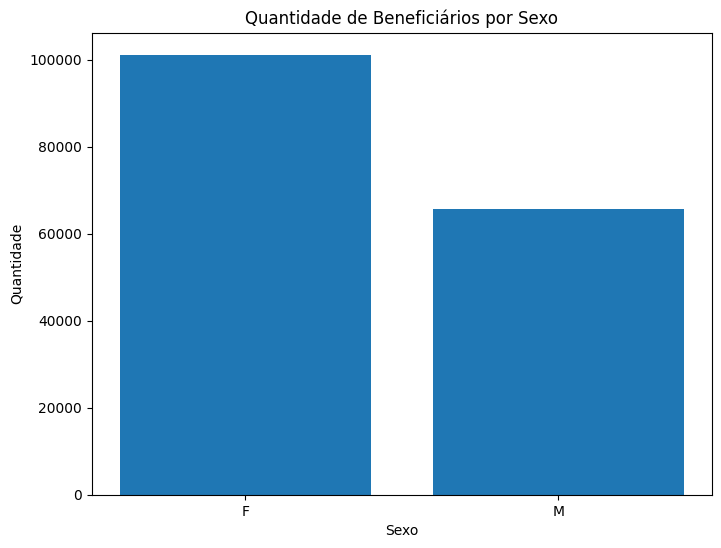

In [ ]:
sex_counts = dados['SEXO_BENEFICIARIO'].value_counts()
plt.figure(figsize=(8, 6))
plt.bar(sex_counts.index, sex_counts.values)
plt.title('Quantidade de Beneficiários por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Quantidade')
plt.show()

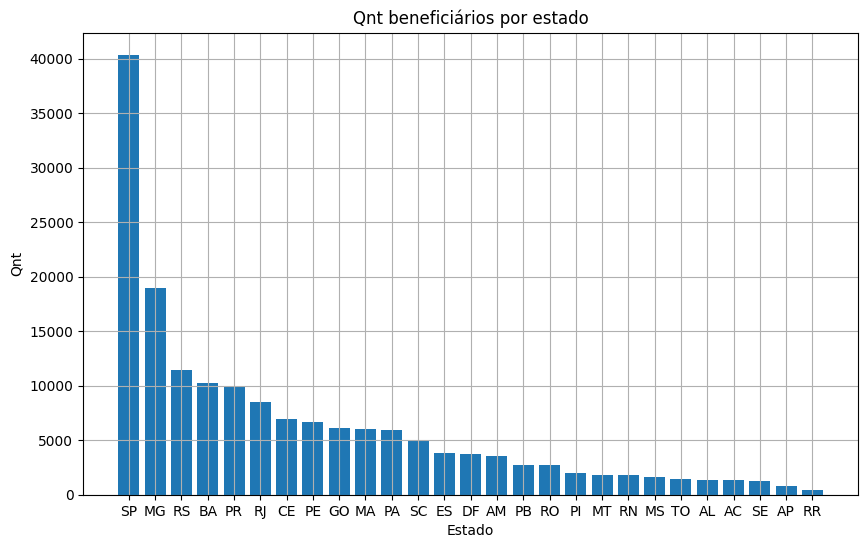

------------------------------------------------


,count
UF_BENEFICIARIO,
SP,40379
MG,18938
RS,11482
BA,10253
PR,9919
RJ,8488
CE,6965
PE,6710
GO,6095


In [ ]:
contagem_regiao = dados['UF_BENEFICIARIO'].value_counts()
plt.figure(figsize=(10, 6))
plt.bar(contagem_regiao.index, contagem_regiao.values)
plt.title('Qnt beneficiários por estado')
plt.xlabel('Estado')
plt.ylabel('Qnt')
plt.grid(True)
plt.show()
print("------------------------------------------------")
dados['UF_BENEFICIARIO'].value_counts()

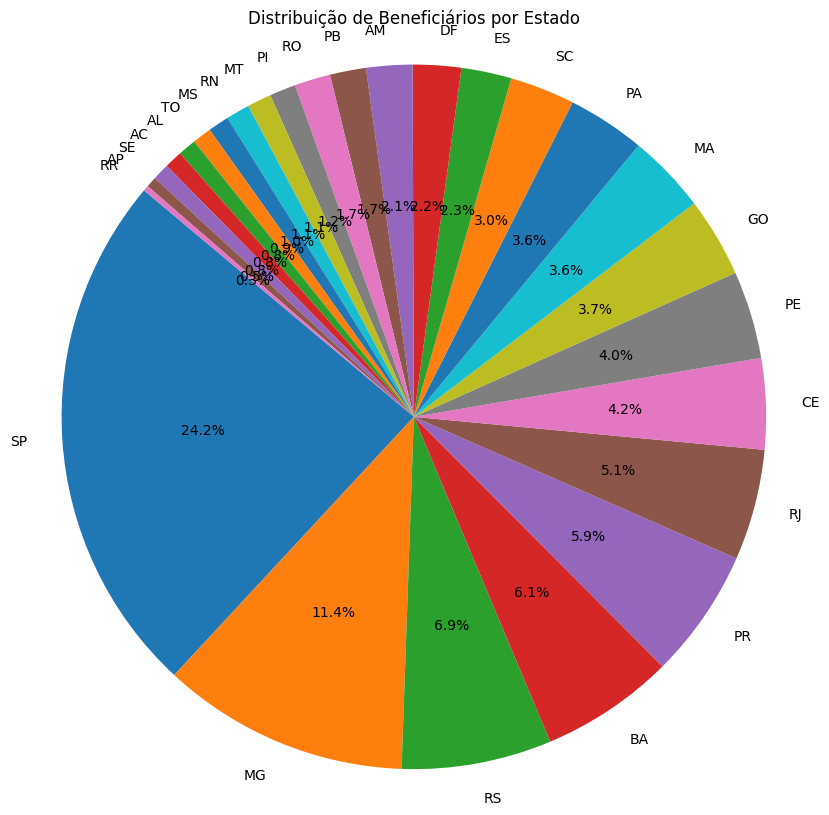

In [ ]:
contagem_regiao = dados['UF_BENEFICIARIO'].value_counts()

plt.figure(figsize=(10, 10))
plt.pie(contagem_regiao.values, labels=contagem_regiao.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribuição de Beneficiários por Estado')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [ ]:
qnt_municipio = dados.groupby('UF_BENEFICIARIO')['MUNICIPIO_BENEFICIARIO'].nunique()
print(qnt_municipio)

UF_BENEFICIARIO
AC     22
AL     95
AM     50
AP     15
BA    406
CE    179
DF      1
ES     78
GO    203
MA    208
MG    800
MS     69
MT    123
PA    135
PB    209
PE    181
PI    183
PR    371
RJ     90
RN    147
RO     52
RR     13
RS    459
SC    266
SE     70
SP    594
TO    105
Name: MUNICIPIO_BENEFICIARIO, dtype: int64


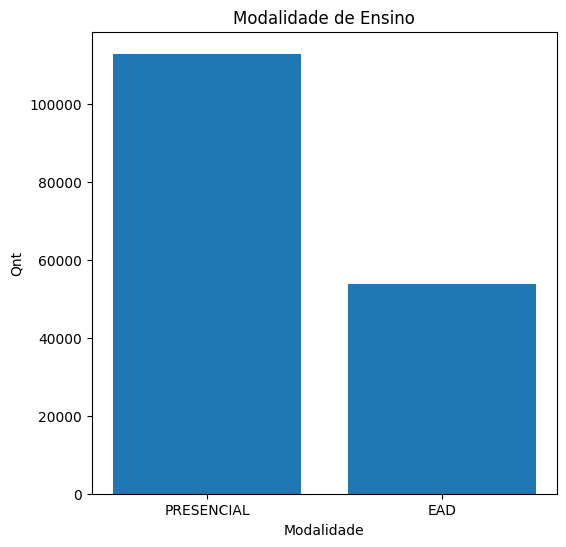

In [ ]:
modalidade_ensino = dados['MODALIDADE_ENSINO_BOLSA'].value_counts()
plt.figure(figsize=(6,6))
plt.bar(modalidade_ensino.index, modalidade_ensino.values)
plt.title('Modalidade de Ensino')
plt.xlabel('Modalidade')
plt.ylabel('Qnt')
plt.show()

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'DIREITO'),
  Text(1, 0, 'ADMINISTRAÇÃO'),
  Text(2, 0, 'PEDAGOGIA'),
  Text(3, 0, 'ENFERMAGEM'),
  Text(4, 0, 'CIÊNCIAS CONTÁBEIS'),
  Text(5, 0, 'EDUCAÇÃO FÍSICA'),
  Text(6, 0, 'PSICOLOGIA'),
  Text(7, 0, 'GESTÃO DE RECURSOS HUMANOS'),
  Text(8, 0, 'FISIOTERAPIA'),
  Text(9, 0, 'FARMÁCIA')])

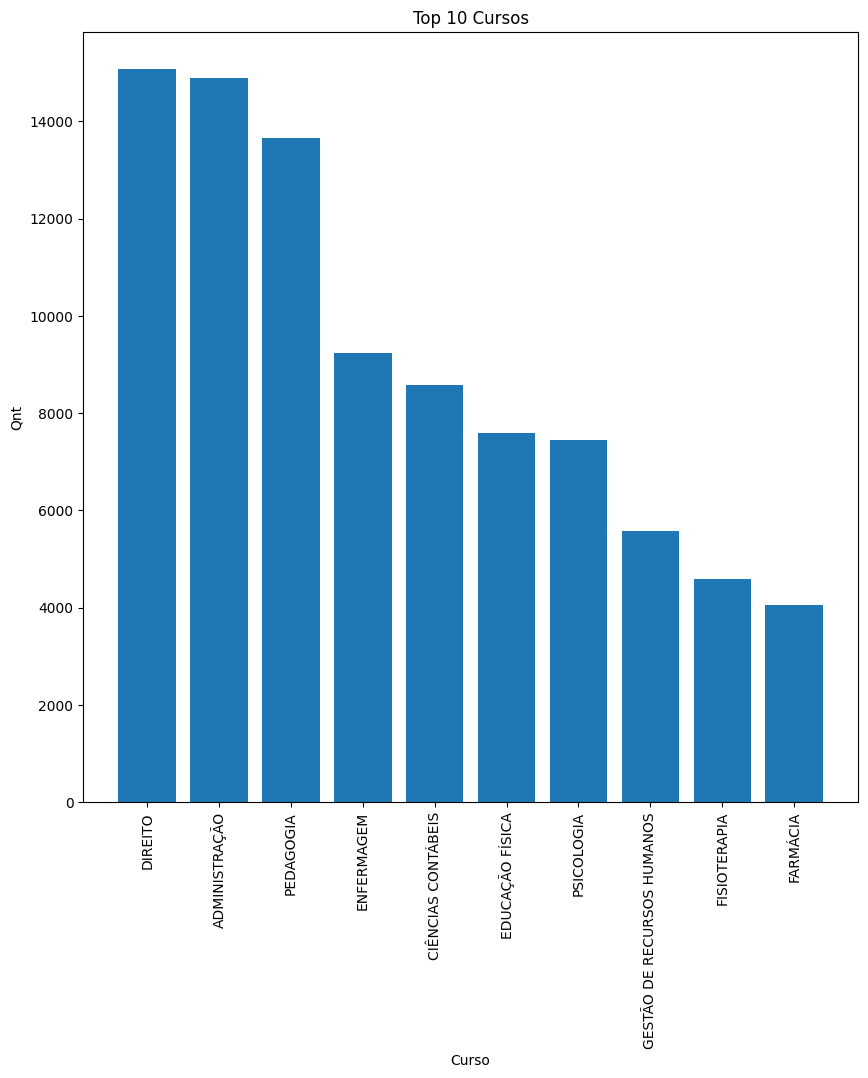

In [ ]:
nome_curso = dados['NOME_CURSO_BOLSA'].value_
counts()
plt.figure(figsize=(10, 10))
plt.bar(nome_curso.index[:10], nome_curso.values[:10])
plt.title('Top 10 Cursos')
plt.xlabel('Curso')
plt.ylabel('Qnt')
plt.xticks(rotation=90)

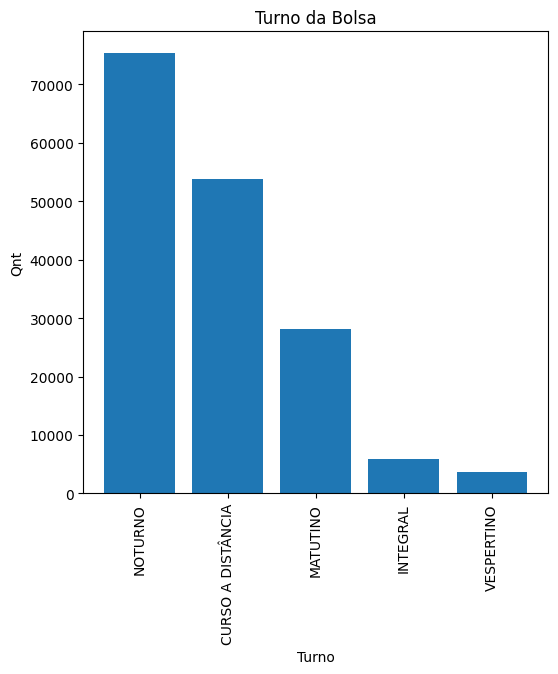

In [ ]:
turno_bolsa = dados['NOME_TURNO_CURSO_BOLSA'].value_counts()
plt.figure(figsize=(6,6))
plt.bar(turno_bolsa.index, turno_bolsa.values)
plt.title('Turno da Bolsa')
plt.xlabel('Turno')
plt.ylabel('Qnt')
plt.xticks(rotation=90)
plt.show()

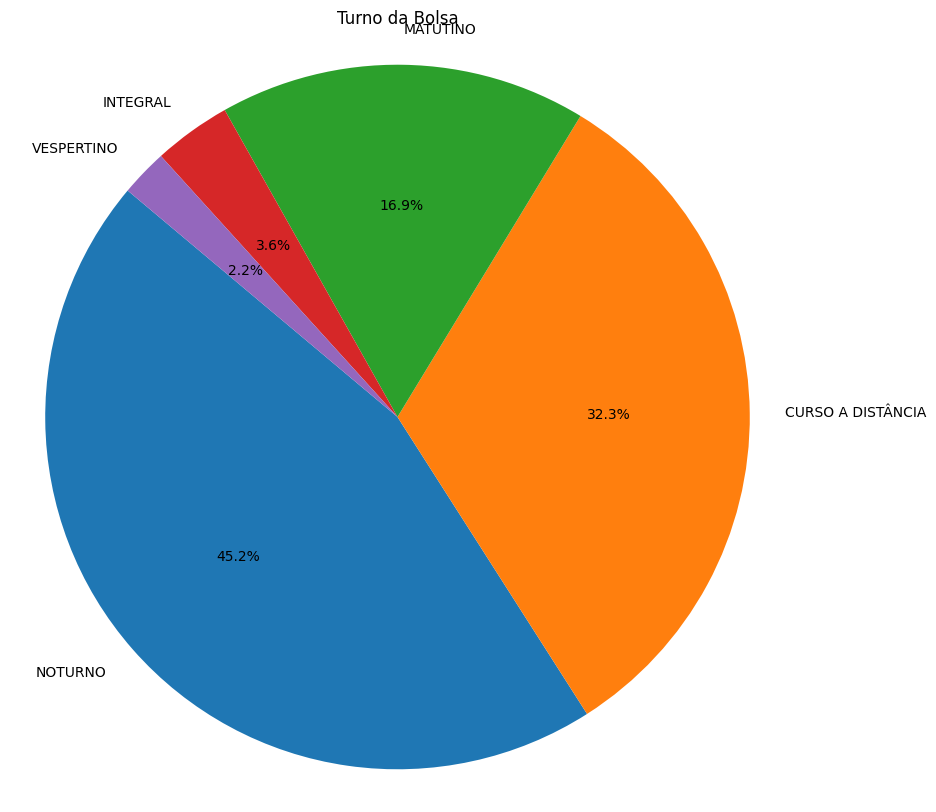

In [ ]:
turno_bolsa = dados['NOME_TURNO_CURSO_BOLSA'].value_counts()

plt.figure(figsize=(10, 10))
plt.pie(turno_bolsa.values, labels=turno_bolsa.index, autopct='%1.1f%%', startangle=140)
plt.title('Turno da Bolsa')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

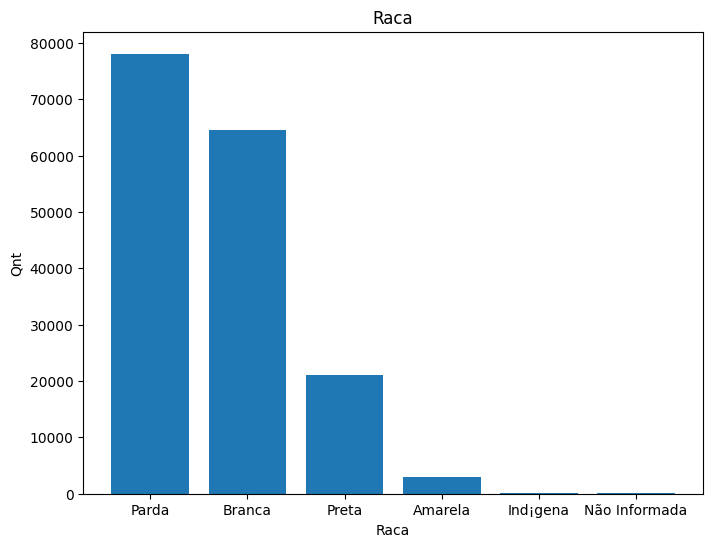

In [ ]:
dados_racas = dados['RACA_BENEFICIARIO'].value_counts()
plt.figure(figsize=(8,6))
plt.bar(dados_racas.index, dados_racas.values)
plt.title('Raca')
plt.xlabel('Raca')
plt.ylabel('Qnt')
plt.show()

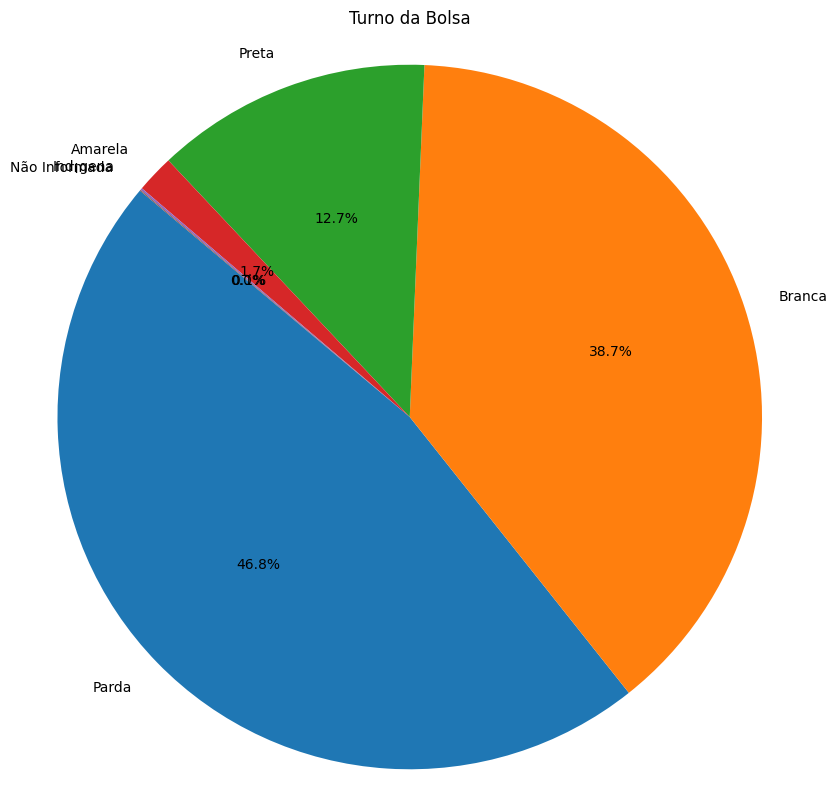

In [ ]:
dados_racas = dados['RACA_BENEFICIARIO'].value_counts()
plt.figure(figsize=(10, 10))
plt.pie(dados_racas.values, labels=dados_racas.index, autopct='%1.1f%%', startangle=140)
plt.title('Turno da Bolsa')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

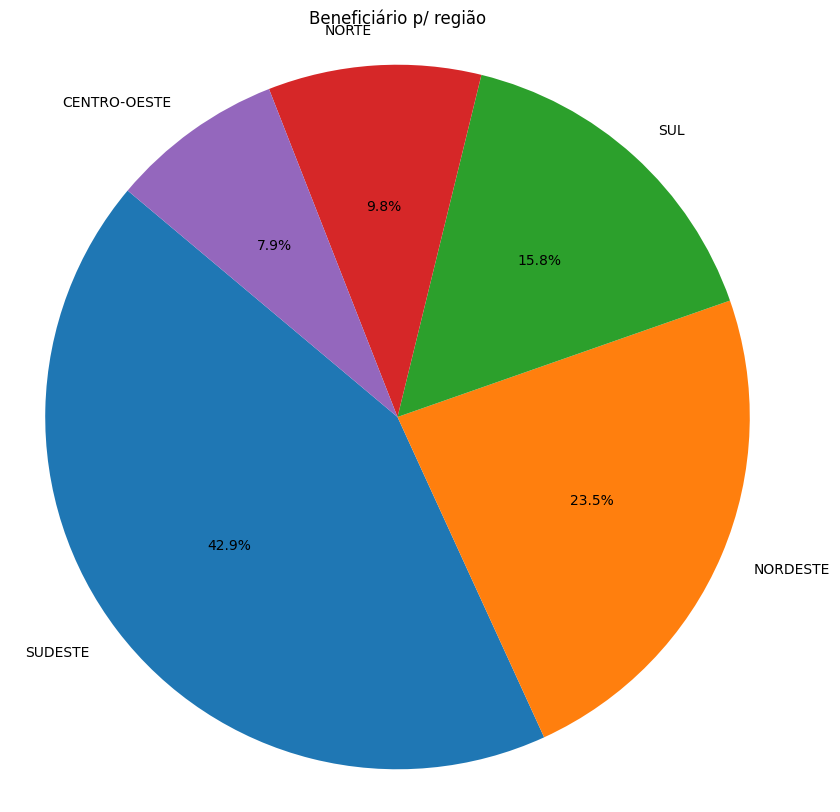

In [ ]:
dados_regiao = dados['REGIAO_BENEFICIARIO'].value_counts()
plt.figure(figsize=(10, 10))
plt.pie(dados_regiao.values, labels=dados_regiao.index, autopct='%1.1f%%', startangle=140)
plt.title('Beneficiário p/ região')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [ ]:
estados = dados['UF_BENEFICIARIO'].value_counts()


In [ ]:
unique_states = dados['UF_BENEFICIARIO'].unique().tolist()

In [ ]:
for state in unique_states:
    # The code to filter the data and create histograms for each state will be added here in subsequent steps.
    pass

In [ ]:
for state in unique_states:
    df_state = dados[dados['UF_BENEFICIARIO'] == state].copy()
    df_presencial = df_state[df_state['MODALIDADE_ENSINO_BOLSA'] == 'PRESENCIAL']
    df_ead = df_state[df_state['MODALIDADE_ENSINO_BOLSA'] == 'EAD']

In [ ]:
for state in unique_states:
    df_state = dados[dados['UF_BENEFICIARIO'] == state].copy()
    df_presencial = df_state[df_state['MODALIDADE_ENSINO_BOLSA'] == 'PRESENCIAL'].copy()
    df_ead = df_state[df_state['MODALIDADE_ENSINO_BOLSA'] == 'EAD'].copy()

    df_presencial['IDADE'] = 2025 - df_presencial['DATA_NASCIMENTO'].dt.year
    df_ead['IDADE'] = 2025 - df_ead['DATA_NASCIMENTO'].dt.year

    plt.figure(figsize=(10, 6))
    plt.hist(df_presencial['IDADE'].dropna(), bins=20, alpha=0.7, label='PRESENCIAL')
    plt.hist(df_ead['IDADE'].dropna(), bins=20, alpha=0.7, label='EAD')
    plt.title(f'Distribuição de Idade por Modalidade em {state}')
    plt.xlabel('Idade')
    plt.ylabel('Quantidade')
    plt.legend()
    plt.show()

AttributeError: Can only use .dt accessor with datetimelike values

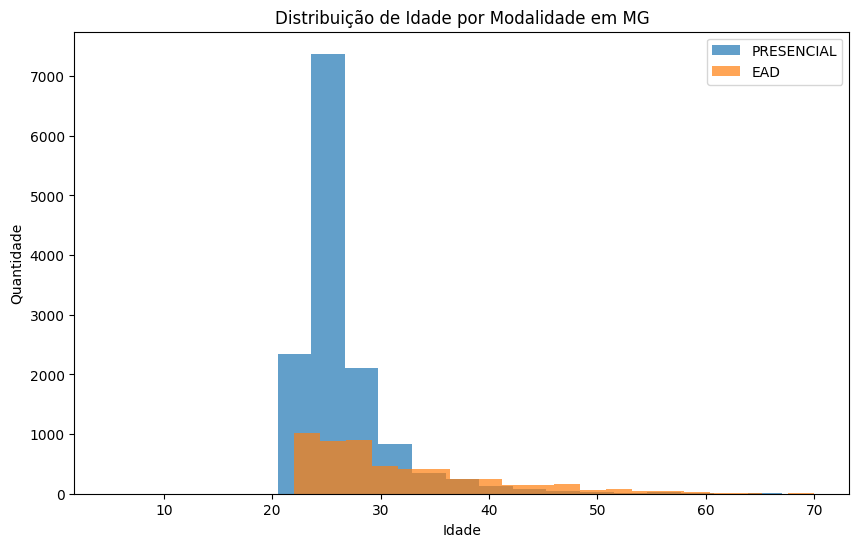

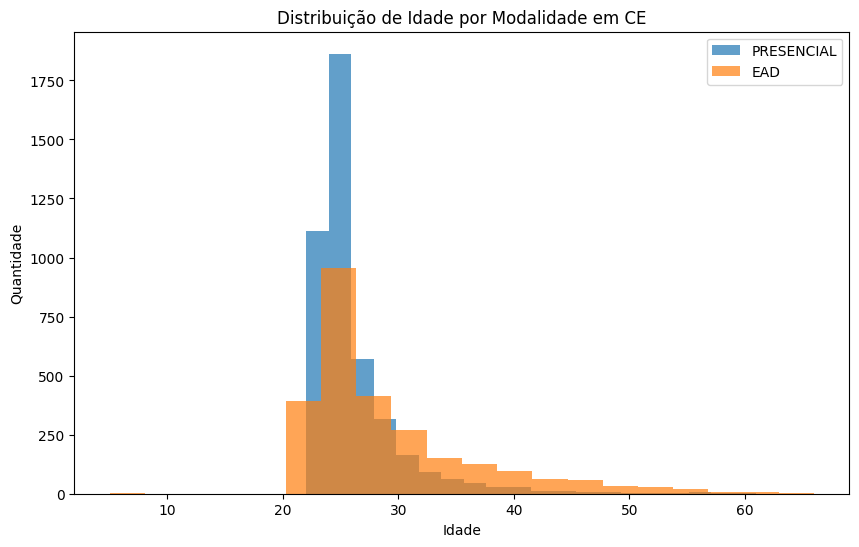

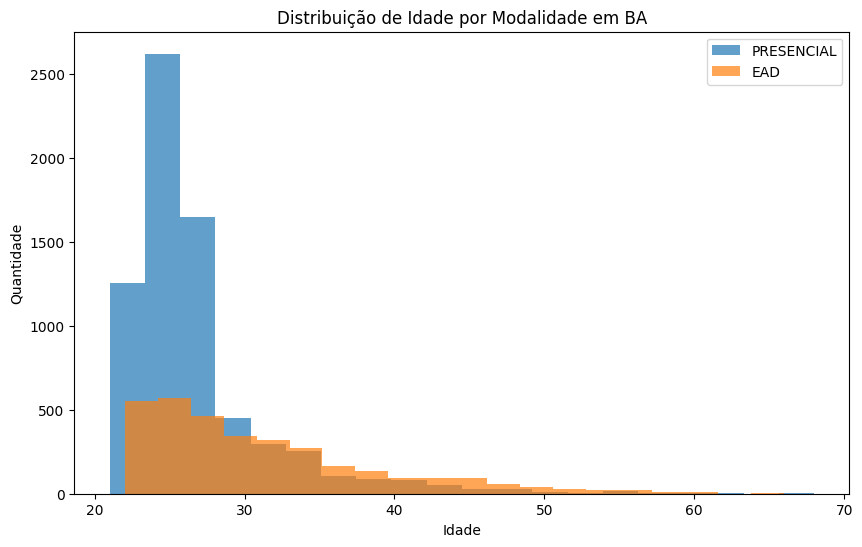

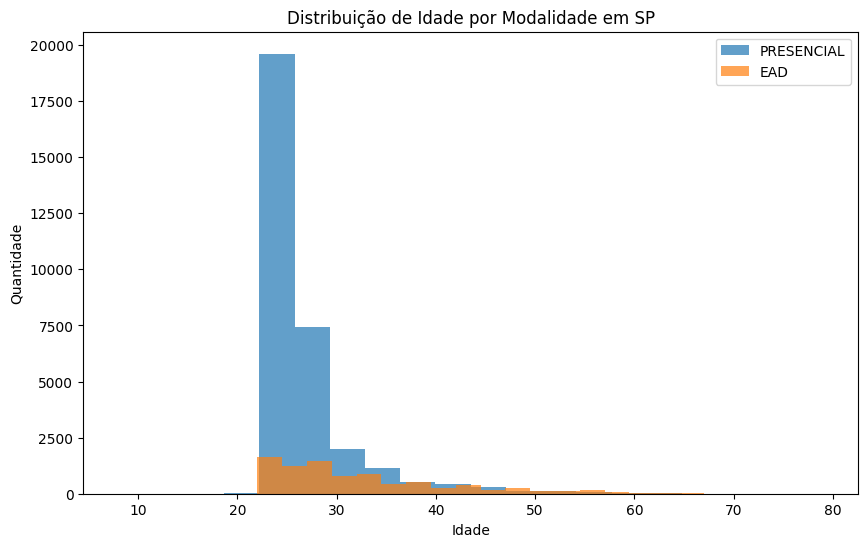

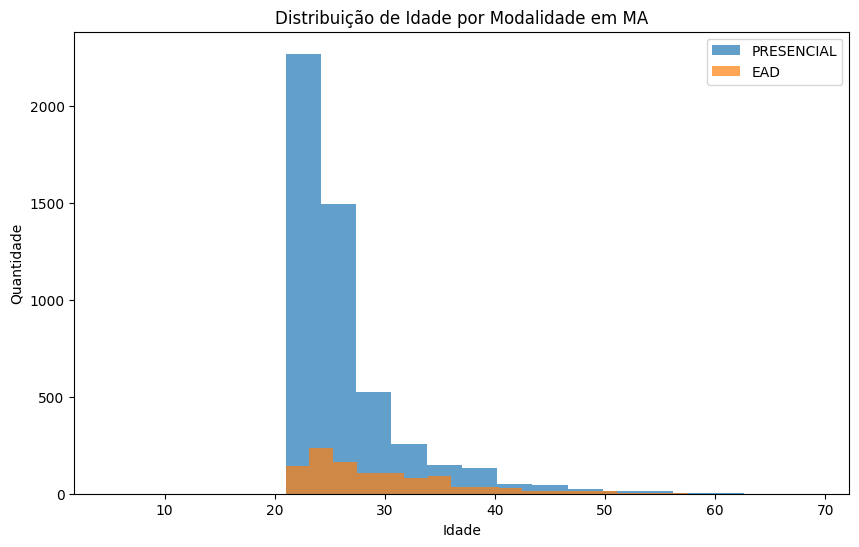

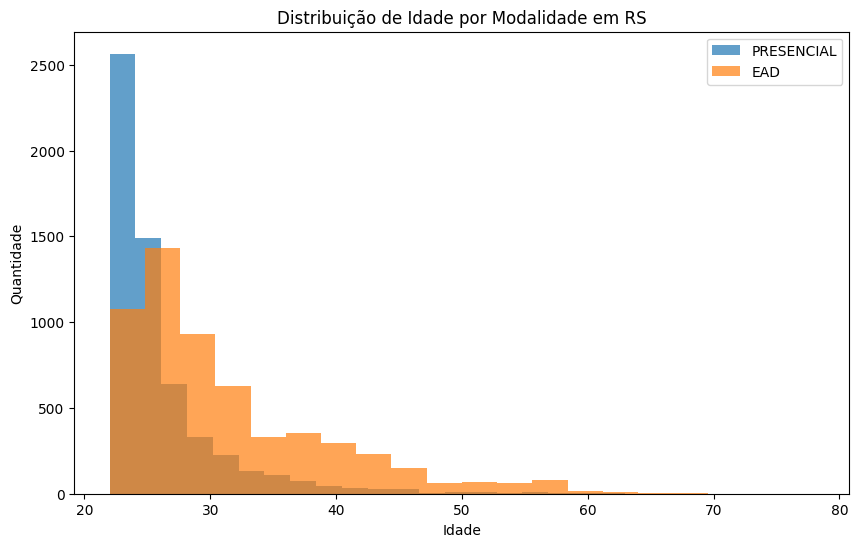

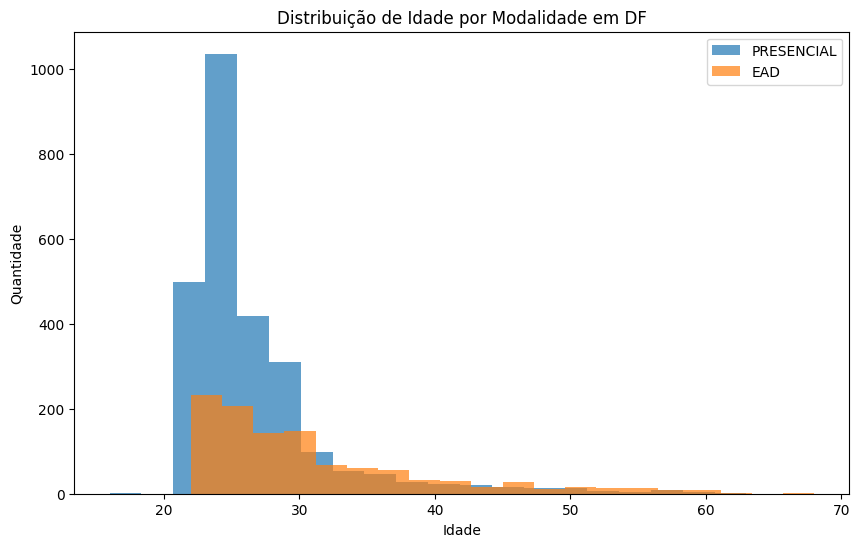

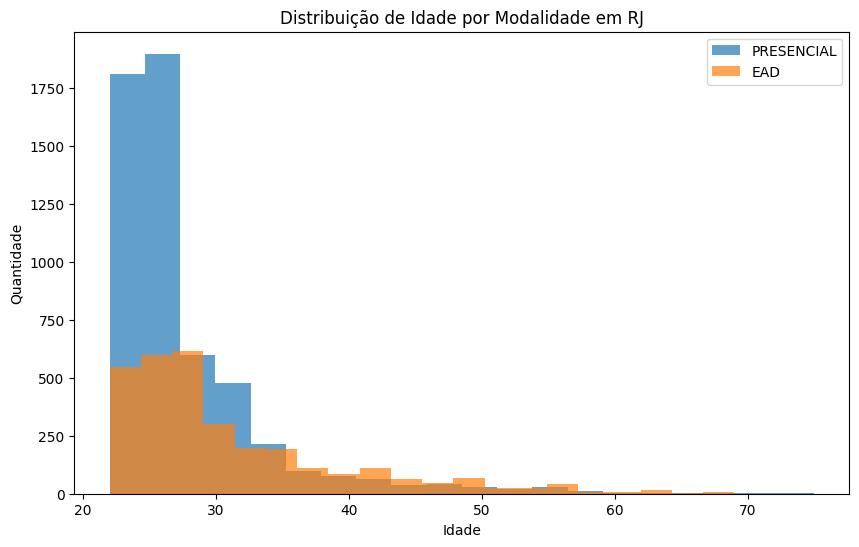

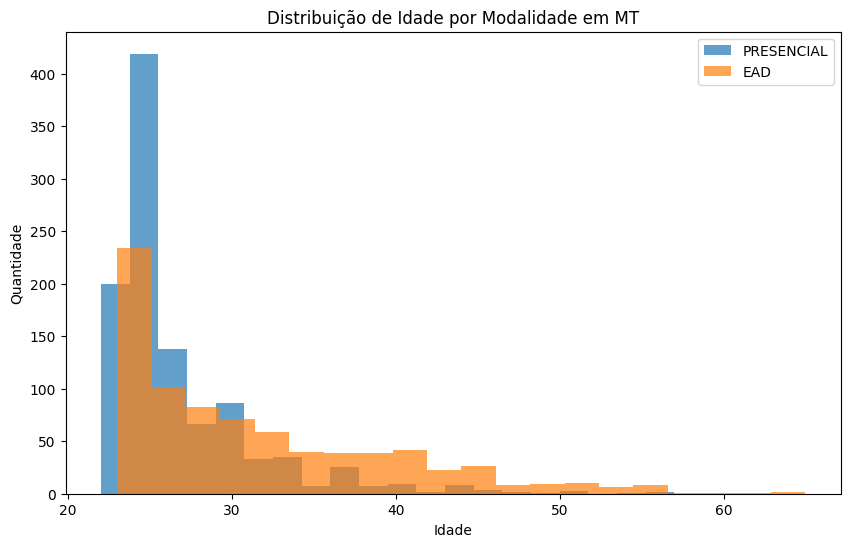

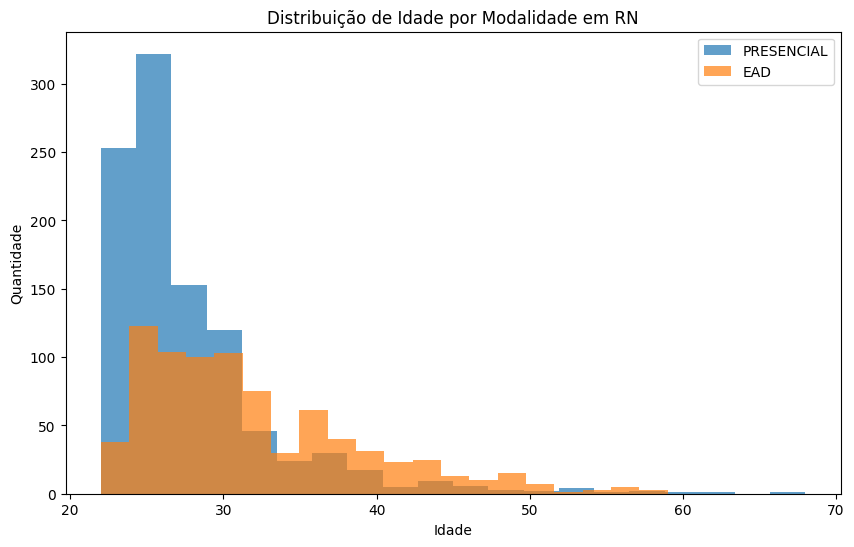

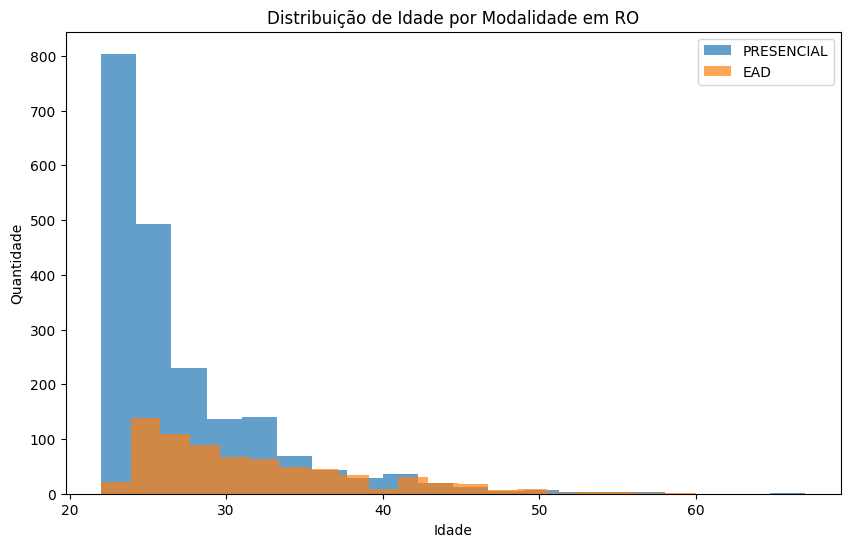

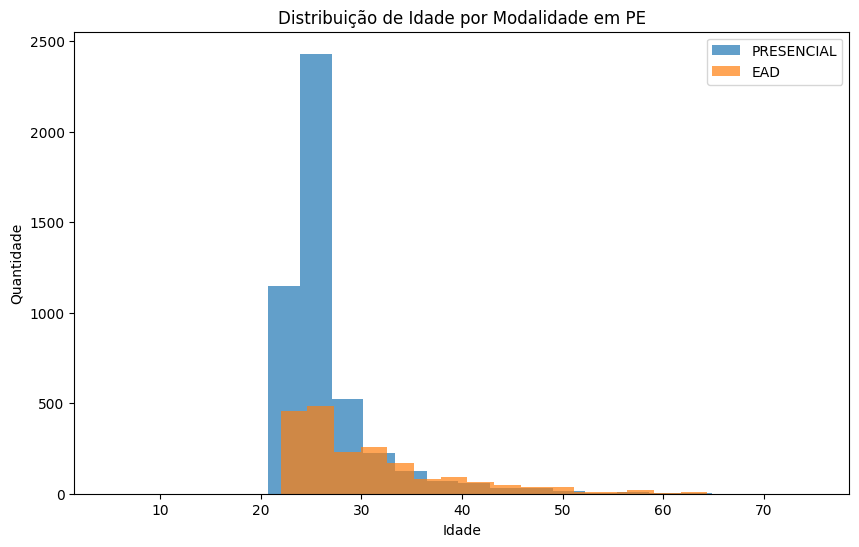

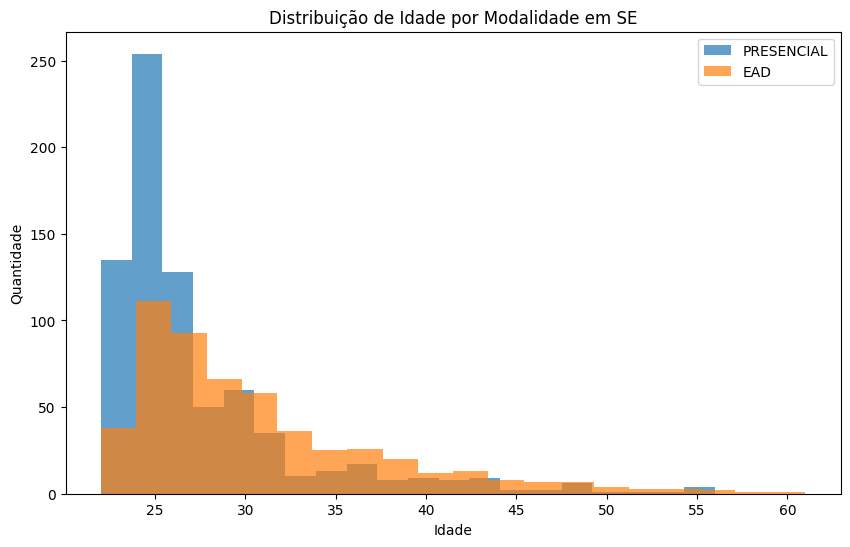

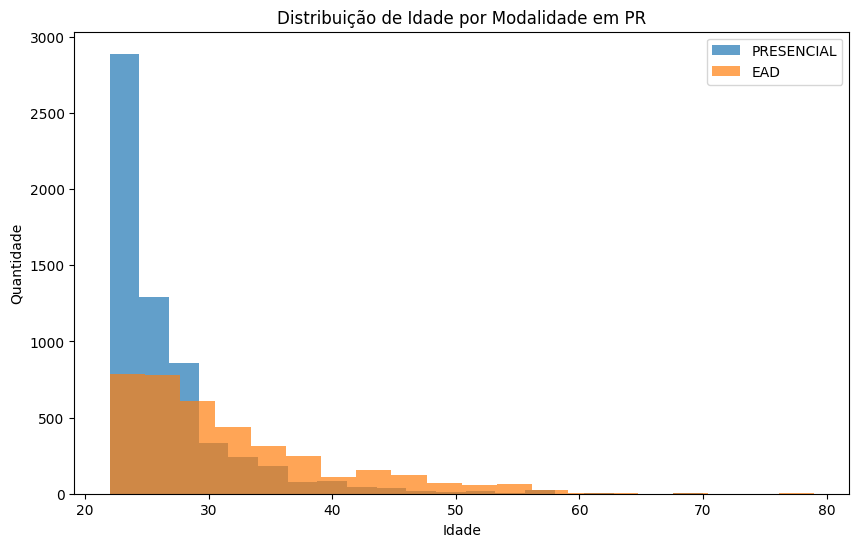

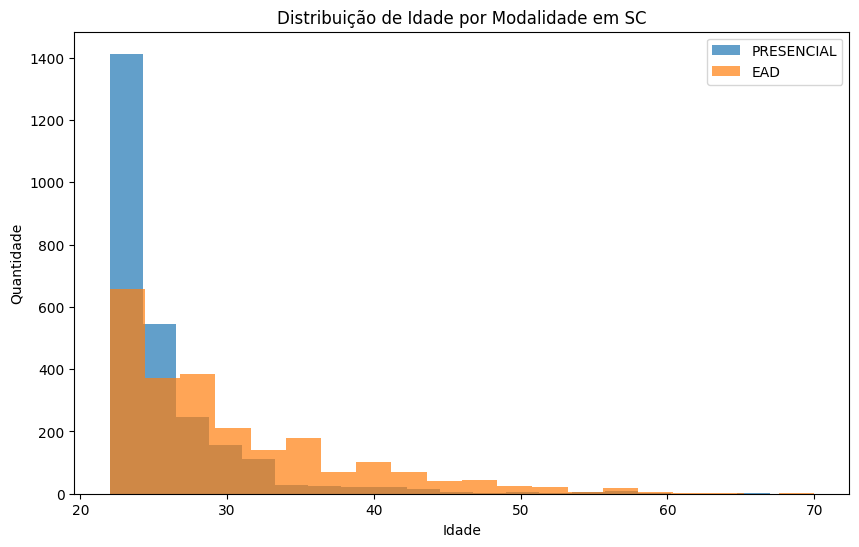

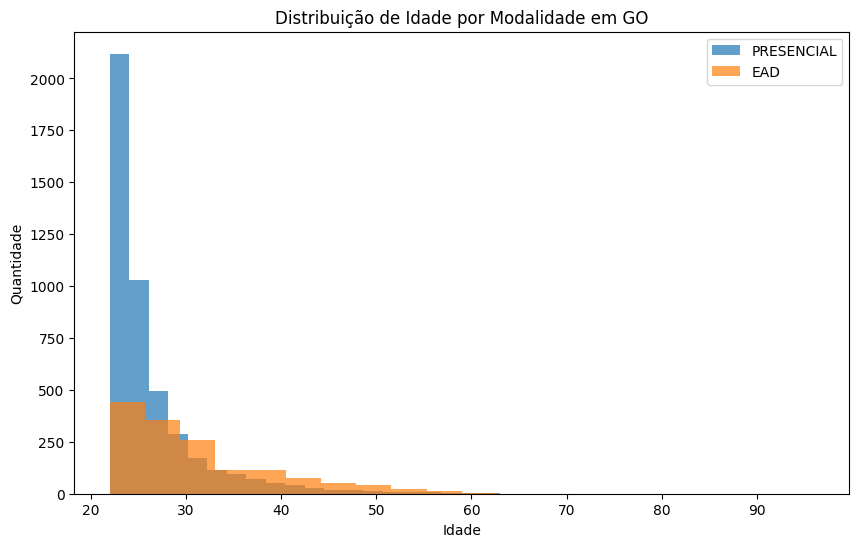

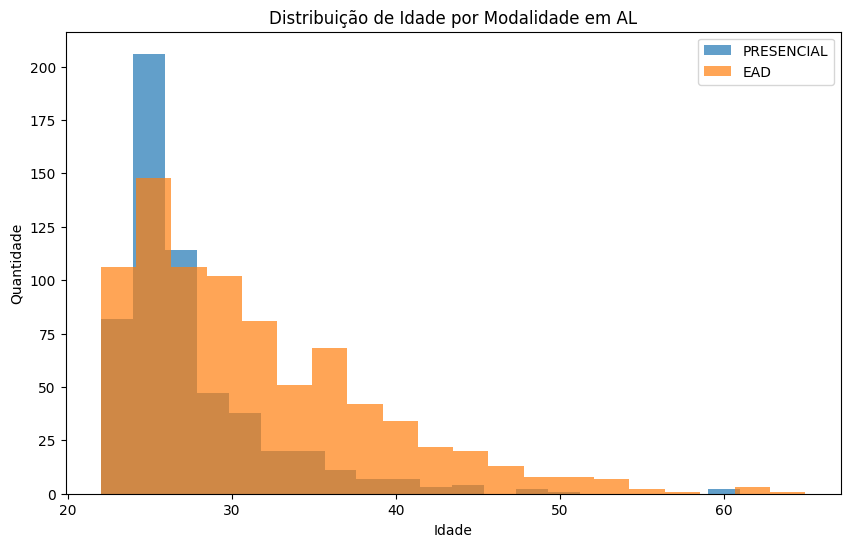

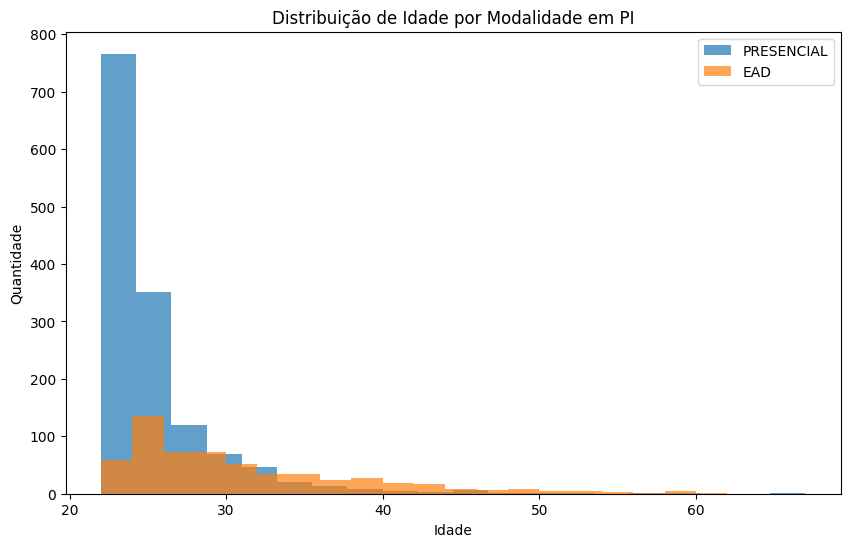

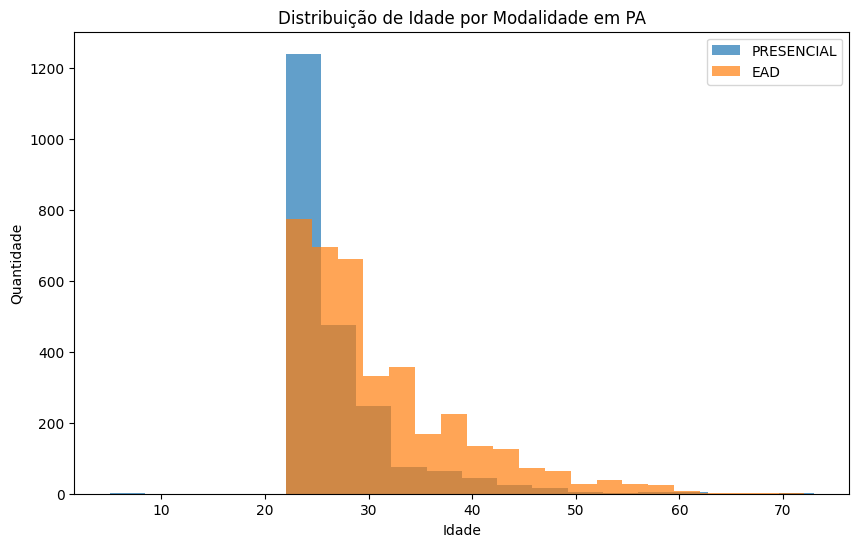

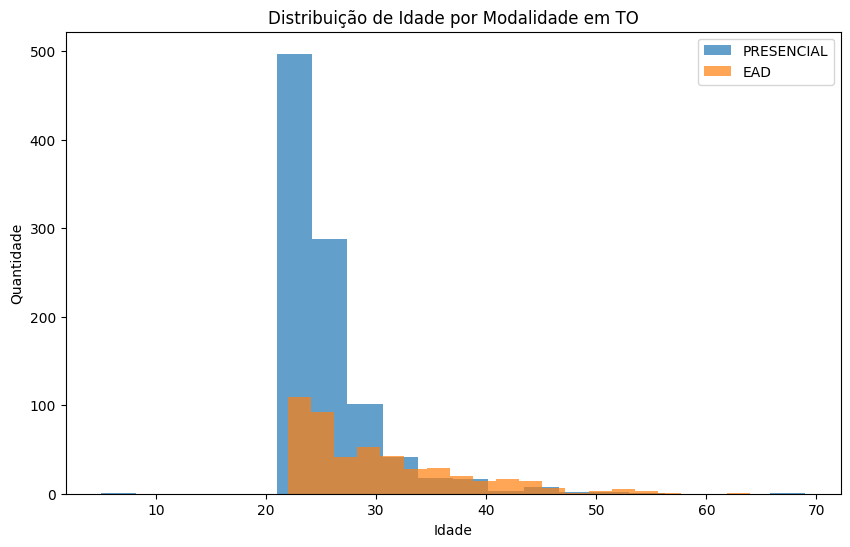

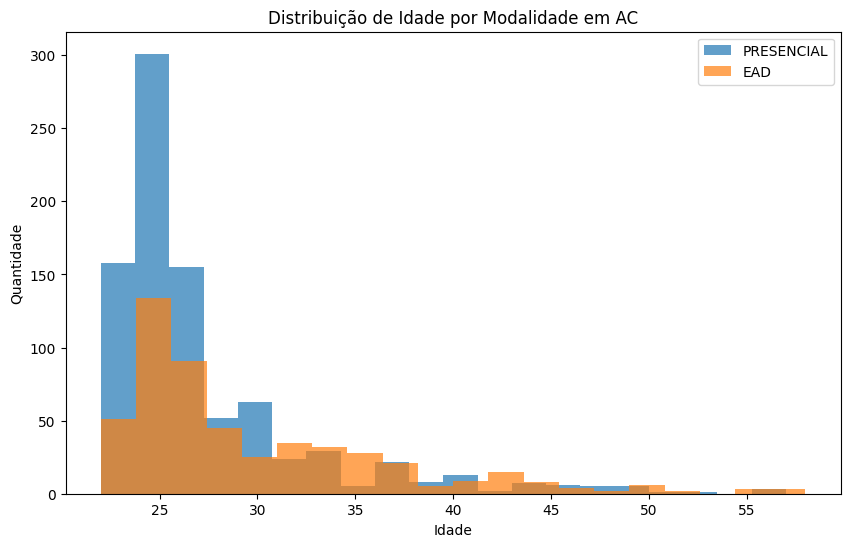

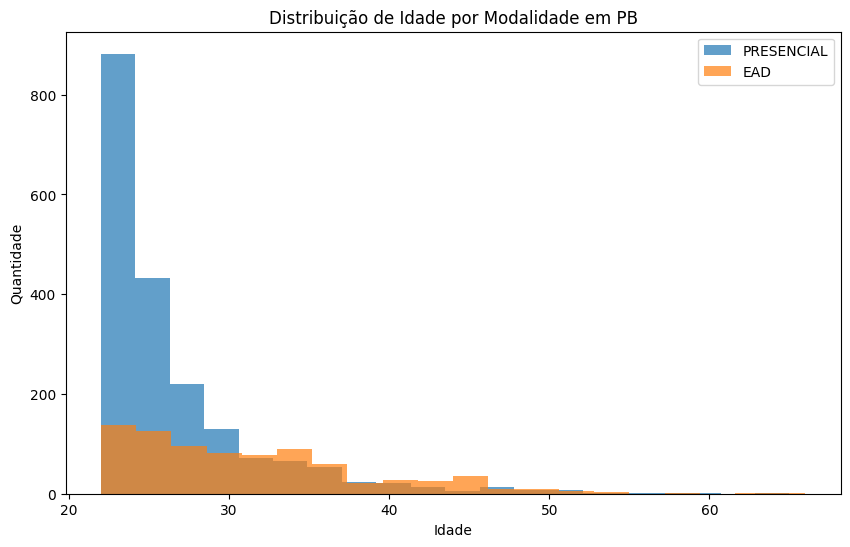

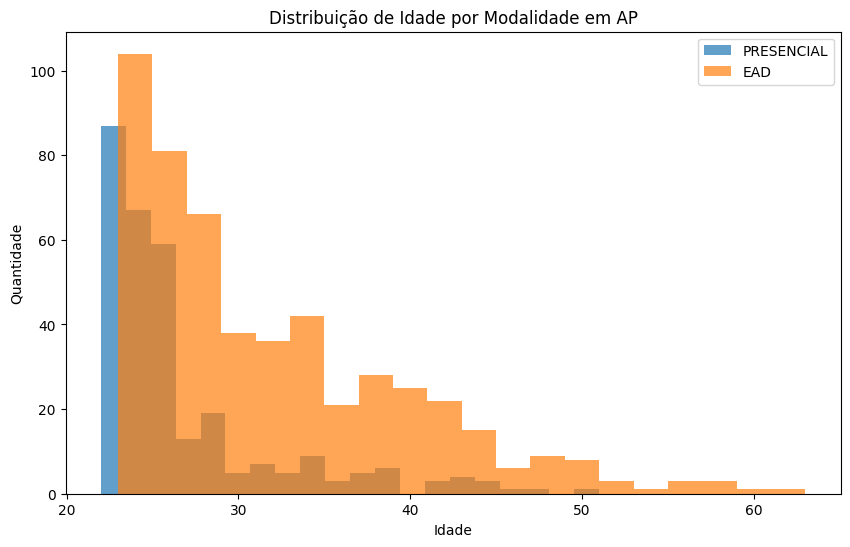

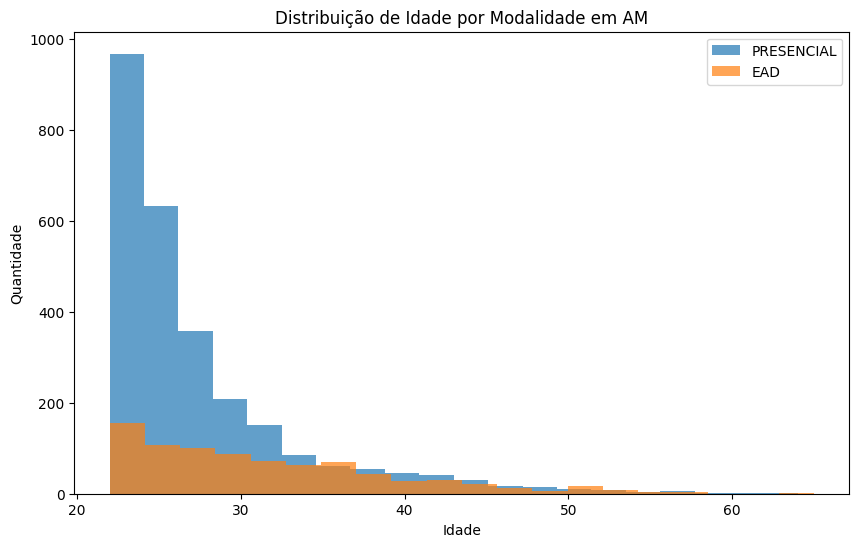

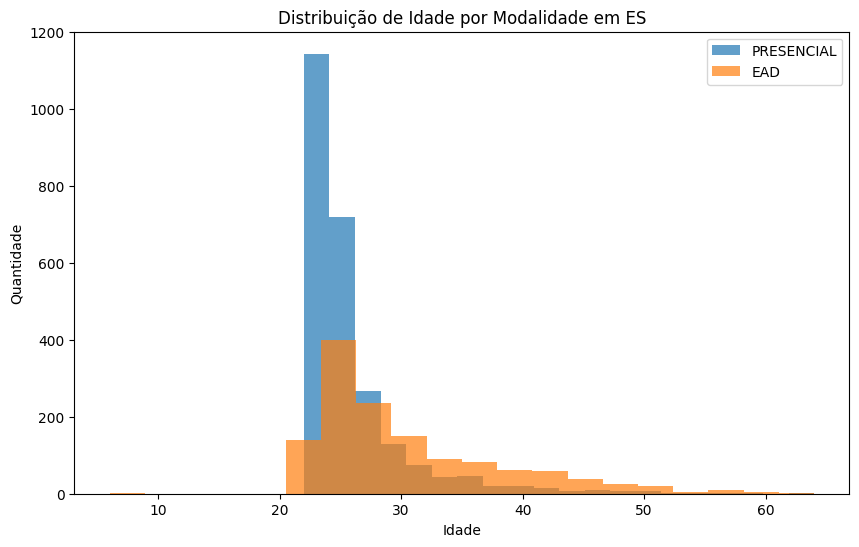

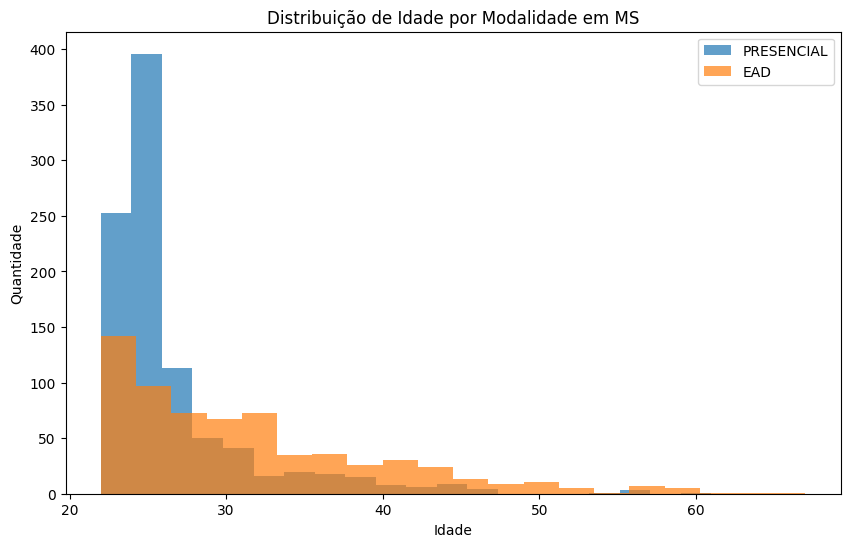

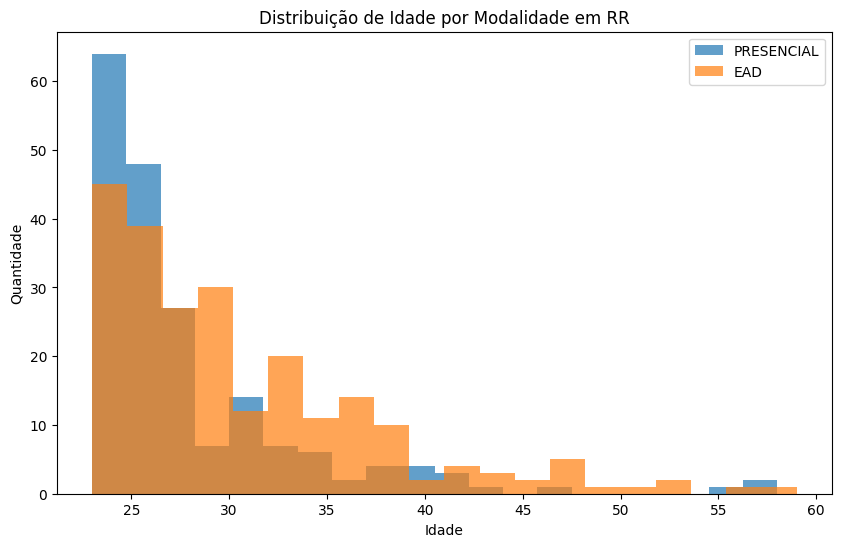

In [ ]:
for state in unique_states:
    df_state = dados[dados['UF_BENEFICIARIO'] == state].copy()

    # Convert 'DATA_NASCIMENTO' to datetime for filtered dataframes
    df_state['DATA_NASCIMENTO'] = pd.to_datetime(df_state['DATA_NASCIMENTO'], format='%d/%m/%Y', errors='coerce')

    df_presencial = df_state[df_state['MODALIDADE_ENSINO_BOLSA'] == 'PRESENCIAL'].copy()
    df_ead = df_state[df_state['MODALIDADE_ENSINO_BOLSA'] == 'EAD'].copy()

    df_presencial['IDADE'] = 2025 - df_presencial['DATA_NASCIMENTO'].dt.year
    df_ead['IDADE'] = 2025 - df_ead['DATA_NASCIMENTO'].dt.year

    plt.figure(figsize=(10, 6))
    plt.hist(df_presencial['IDADE'].dropna(), bins=20, alpha=0.7, label='PRESENCIAL')
    plt.hist(df_ead['IDADE'].dropna(), bins=20, alpha=0.7, label='EAD')
    plt.title(f'Distribuição de Idade por Modalidade em {state}')
    plt.xlabel('Idade')
    plt.ylabel('Quantidade')
    plt.legend()
    plt.show()